In [82]:
# Create a model to predict the selling price of the car. Split the data for prediction purposes.

# Exploration & Cleaning

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [84]:
car_data = pd.read_csv('car_dataset.csv')
car_data


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [85]:
print(np.mean(car_data['selling_price']))

638271.8077017716


In [86]:
#For both of these we don't want extreme outliers skewing the data
car_data = car_data[car_data['km_driven'] < 300000] #cars shouldn't run longer than this
car_data = car_data[car_data['selling_price'] < 8000000] #There are a few cars selling for over $8,000,000

In [87]:
car_data['mileage_numeric'] = car_data['mileage'].str.replace(r'[^0-9.]', '', regex=True).replace('Nan', '0', regex= False).astype(float)

In [88]:
car_data['max_power_numeric'] = car_data['max_power'].str.replace(r'[^0-9.]', '', regex=True).replace('', '0').fillna('0').astype(float)


In [89]:
car_data['selling_price'].corr(car_data['max_power_numeric'])

0.7189260206922332

<Axes: xlabel='year', ylabel='selling_price'>

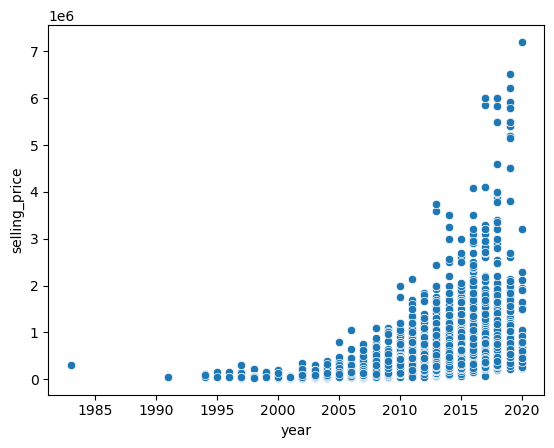

In [90]:
sns.scatterplot(x = 'year', y = 'selling_price', data = car_data)

<Axes: xlabel='km_driven', ylabel='selling_price'>

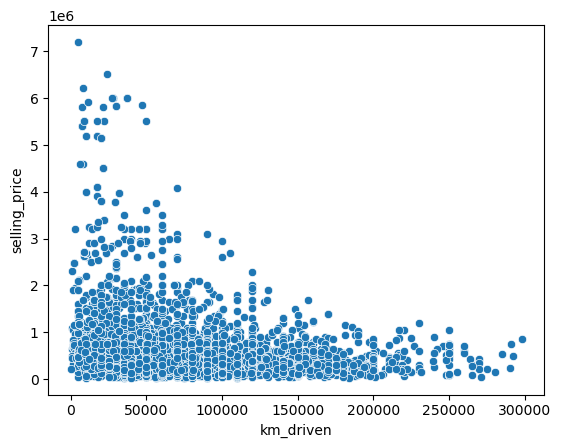

In [91]:
sns.scatterplot(x = 'km_driven', y = 'selling_price', data = car_data)

<Axes: xlabel='mileage_numeric', ylabel='selling_price'>

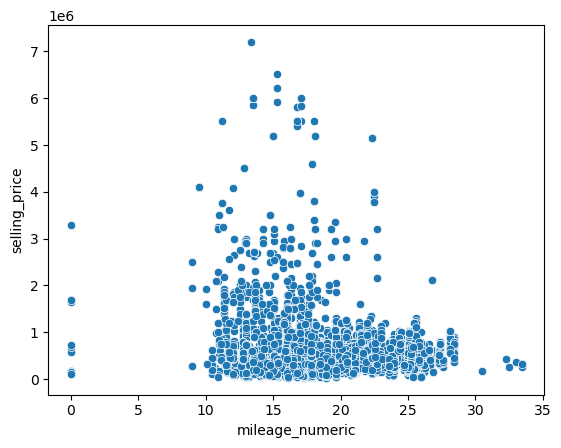

In [92]:
sns.scatterplot(x = 'mileage_numeric', y = 'selling_price', data = car_data)

<Axes: xlabel='max_power_numeric', ylabel='selling_price'>

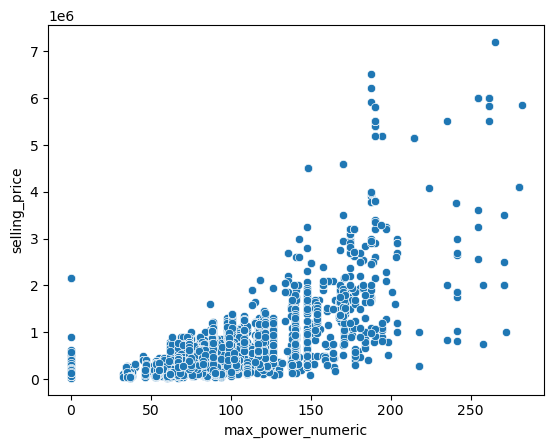

In [93]:
sns.scatterplot(x = 'max_power_numeric', y = 'selling_price', data = car_data)

# Split

Things to train on:  
km_driven,  
year,  
max_power_numeric

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score



In [95]:
X = car_data[['year','km_driven','max_power_numeric']]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
y = car_data[['selling_price']]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size= 0.3
)


# Build Regression Model

In [97]:
#I am randomly choosing and adjusting alpha. I am using the l2 penalty because I have already pre-screened the input variables and know that they are not meaningless. 
#Nevermind. Wrote that first one before testing all the l1's possible. Turns out the ratio should be 1.
def find_rmse (alpha, l1):    
    eNet = ElasticNet(alpha= alpha, l1_ratio= l1)
    eNet.fit(X_train, y_train)
    preds = eNet.predict(X_test)
    rmse = np.sqrt(mean_squared_error(preds, y_test))
    # print(np.mean(y_test), np.mean(preds))
    
    # print(alpha, " : ", mse)
    return rmse

In [98]:
best_alpha = 1000
best_l1_ratio = 2
rmse_best_alpha = 10000000000000000000000000000
for i in range(0,1000, 20):
    for j in np.arange(0,1.1, 0.2):
        rmse_i = find_rmse(i,j)
        if rmse_i < rmse_best_alpha:
            best_alpha = i
            best_l1_ratio = j
            rmse_best_alpha = mse_i
print(best_alpha, best_l1_ratio, rmse_best_alpha)

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\base.py:1151: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.345e+14, tolerance: 3.535e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

0 0.0 501094.14790716127


c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.766e+15, tolerance: 3.535e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


The best model is actually just a non-adjusted linear regression model.

# Evaluate the Model

In [99]:
eNet = ElasticNet(alpha= best_alpha, l1_ratio=best_l1_ratio)
eNet.fit(X_train, y_train)
preds = eNet.predict(X_test)
rmse = np.sqrt(mean_squared_error(preds, y_test))
mae = mean_absolute_error(preds, y_test)
r_2 = r2_score(preds, y_test)
print("R^2 score: ", r_2, " \n MAE: ", mae, "\n RSME: ", rmse)

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\base.py:1151: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


R^2 score:  0.20509178361090075  
 MAE:  314780.2874199583 
 RSME:  546081.7544254399


c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.345e+14, tolerance: 3.535e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


As I have run this a few times, I have noticed that the R^2 score is only about 0.244, meaning the model only explains 24.4% of the variance in the data, which is not great. The mae and rmse are both really high, which also tells me that the model is not fitting the data very well.

# Conclude

In [100]:
coefs = eNet.coef_
print(coefs)

[ 116176.69328057 -118191.9597974   527882.37096278]


The strongest predictor of price is the power. This actually makes sense because both trucks and high-performance vehicles are very expensive and pack in a lot of horsepower. The model does not predict the selling price very well. In the future, polynomial regression will probably work better on this data as prices seem to scale exponentially near the high-end price range. The other thing that would improve it would be to turn more of the categorical variables into training data. I was concerned about using all of the variables and over-fitting the model, but even just making the transmission into part of the training data would likely improve the result as manual transmissions are selling for 1.7x that of automatic tranmission vehicles. 